In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

T = np.array([115, 105, 56.9, 51.5, 31.5, 29, 0])
R = np.array([232, 300, 900, 1108, 2340, 2700, 9580])

xdata = R
ydata = T

def steinhart_hart(R, a, b, c):
    """fit thermistor resistance to the Steinhart-Hart model for T
    @param R: resistance in ohms
    @param a, b, c: fitting parameters
    @return: 1/temperature_degK
    """
    log_R = np.log(R)
    return 1/(a + b*log_R + c*np.power(log_R, 3))

popt, pcov = curve_fit(steinhart_hart, R, 1/(T+273.15))

def def_R2T(popt):
    def R2T(R):
        recip_Tk = steinhart_hart(R, *popt)
        degC = 1/recip_Tk - 273.15
    
        return degC
    return R2T

R2T = def_R2T(popt)


display(popt)
display(pcov)

array([ 6.85243040e+02, -6.00512143e+01,  1.80427980e-01])

array([[ 6.20267517e+02, -1.24555739e+02,  6.97380669e-01],
       [-1.24555739e+02,  2.52462820e+01, -1.43429297e-01],
       [ 6.97380669e-01, -1.43429297e-01,  8.36348228e-04]])

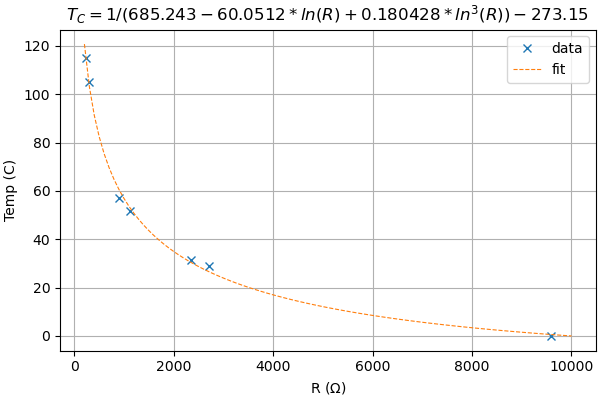

In [2]:
# data for plotting fit
rr = np.linspace(200, 1e4, 100)
tout = R2T(rr)

ax = plt.figure(figsize=(6,4), constrained_layout=True).gca()

pf = ax.plot

pf(R, T, 'x', label="data")
pf(rr, tout, '--', linewidth=0.8, label="fit")
ax.grid(True)
ax.set_xlabel("R ($\Omega$)")
ax.set_ylabel("Temp (C)")
ax.legend()
ax.set_title(f"$T_C = 1/({popt[0]:.3f}-{-popt[1]:.4f}*ln(R)+{popt[2]:.6f}*ln^3(R)) - 273.15$")
None

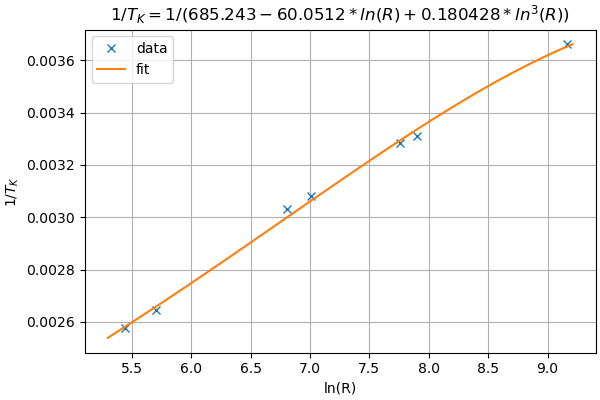

In [3]:
# data for plotting fit
rr = np.linspace(200, 1e4, 100)
tout = R2T(rr)

ax = plt.figure(figsize=(6,4), constrained_layout=True).gca()

pf = ax.plot

xd = R
yd = 1/(T+273.15)
xd2 = rr
yd2 = 1/(tout+273.15)

pf(np.log(xd), yd, 'x', label="data")
pf(np.log(xd2), yd2, label="fit")
ax.grid(True)
ax.set_xlabel("ln(R)")
ax.set_ylabel("$1/T_K$")
ax.legend()
ax.set_title(f"$1/T_K = 1/({popt[0]:.3f}-{-popt[1]:.4f}*ln(R)+{popt[2]:.6f}*ln^3(R))$")
None

In [4]:
# 
# Convert degC to resistance and ADC counts, assuming 1K pullup
#
from sympy import Eq, solve, Symbol, symbols
r1, r2, vref = symbols("R1 R2 V_ref")
ss = {r1:1000, vref:3.300}

vo = (vref * r2 / (r1+r2)).subs(ss)
r2_n = np.logspace(np.log10(325), np.log10(10000), 10)
dd = {kk:[] for kk in "R2 degC Vin counts".split()}
for rr in r2_n:
    degC = np.round(R2T(rr), 1)
    vin = float(vo.subs({r2:rr}))
    counts = int(np.round(vin/3.3*65535))
    dd["R2"].append(int(np.round(rr, 0)))
    dd["degC"].append(degC)
    dd["Vin"].append(np.round(vin, 3))
    dd["counts"].append(counts)
    # print(f"{rr:5.0f} ohms, {R2T(rr):5.1f}C, {float(vo.subs({r2:rr})):5.3f}V")

df = pd.DataFrame(dd).set_index("R2")
display(df)
display(Eq(Symbol("V_o"), vo))
display(Eq(Symbol("ADC_{counts}"), vo/3.3*65535))

,degC,Vin,counts
R2,,,
325,99.7,0.809,16075
476,84.2,1.064,21122
696,69.6,1.354,26893
1018,56.1,1.665,33066
1490,43.7,1.975,39219
2181,32.4,2.263,44932
3191,22.4,2.513,49899
4670,13.5,2.718,53977
6834,6.1,2.879,57169


Eq(V_o, 3.3*R2/(R2 + 1000))

Eq(ADC_{counts}, 65535.0*R2/(R2 + 1000))

20.722095711738362 998830559.121509
7.078888760373086 1186.6491340277298
13.643206951365276 841723.581536923


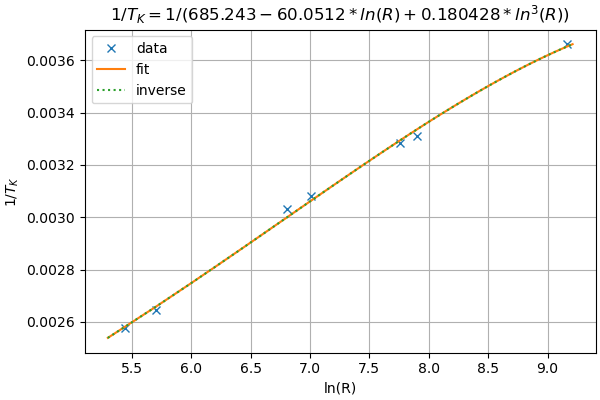

In [18]:
#
# Invert the Steinhart-Hart function to determine R as a function of T
#
a, b, c = symbols("a b c", real=True)
subc = {a:popt[0], b:popt[1], c:popt[2]}

from sympy import symbols, solve, Eq, log

recip_Tk, lnR = symbols("1/T_K log(R)", positive=True, real=True)

# display(recip_Tk)
# display(lnR)
eq_sh = a + b*lnR + c*lnR**3
eqn = Eq(recip_Tk, eq_sh)
# display(eqn)
inv_sols = solve(eqn, lnR)
for ss in inv_sols:
    # display(Eq(lnR, ss))
    val = abs(complex(ss.subs(subc).subs({recip_Tk:(51+273.15)})))
    # pick the inverse that creates a reasonable value
    if 5 < val < 9:
        isol = ss.subs(subc)
    print(val, np.exp(val))

rr = np.linspace(200, 1e4, 100)
tout = R2T(rr)

ax = plt.figure(figsize=(6,4), constrained_layout=True).gca()
xd = R
yd = 1/(T+273.15)
xd2 = rr
yd2 = 1/(tout+273.15)

yd3 = yd2.copy()
xd3 = np.array([abs(complex(isol.subs({recip_Tk:tt}))) for tt in tout+273.15])

ax.plot(np.log(xd), yd, 'x', label="data")
ax.plot(np.log(xd2), yd2, label="fit")
ax.plot(xd3, yd3, ':', label="inverse")
ax.grid(True)
ax.set_xlabel("ln(R)")
ax.set_ylabel("$1/T_K$")
ax.legend()
ax.set_title(f"$1/T_K = 1/({popt[0]:.3f}-{-popt[1]:.4f}*ln(R)+{popt[2]:.6f}*ln^3(R))$")
None